# Gradient (Multivariable Calculus)

A theory-first notebook on gradients, geometric intuition, and computation.

This notebook covers:
- partial derivatives
- the gradient vector
- evaluating gradients at a point
- the geometric meaning of gradients
- tangent plane connection
- contour plots and vector fields
- numerical gradient approximation
- exercises and solutions


## 1. Learning Objectives

By the end of this notebook, you should be able to:

- compute partial derivatives
- build the gradient vector
- evaluate the gradient at a point
- interpret the gradient geometrically
- understand why the gradient points in the direction of steepest increase
- visualize gradients using contour plots and vector fields


## 2. Geometric Motivation

For a scalar field $f(x,y)$, changing $x$ while holding $y$ constant gives one rate of change.

Changing $y$ while holding $x$ constant gives another rate of change.

The **gradient** bundles these partial rates of change into one vector.

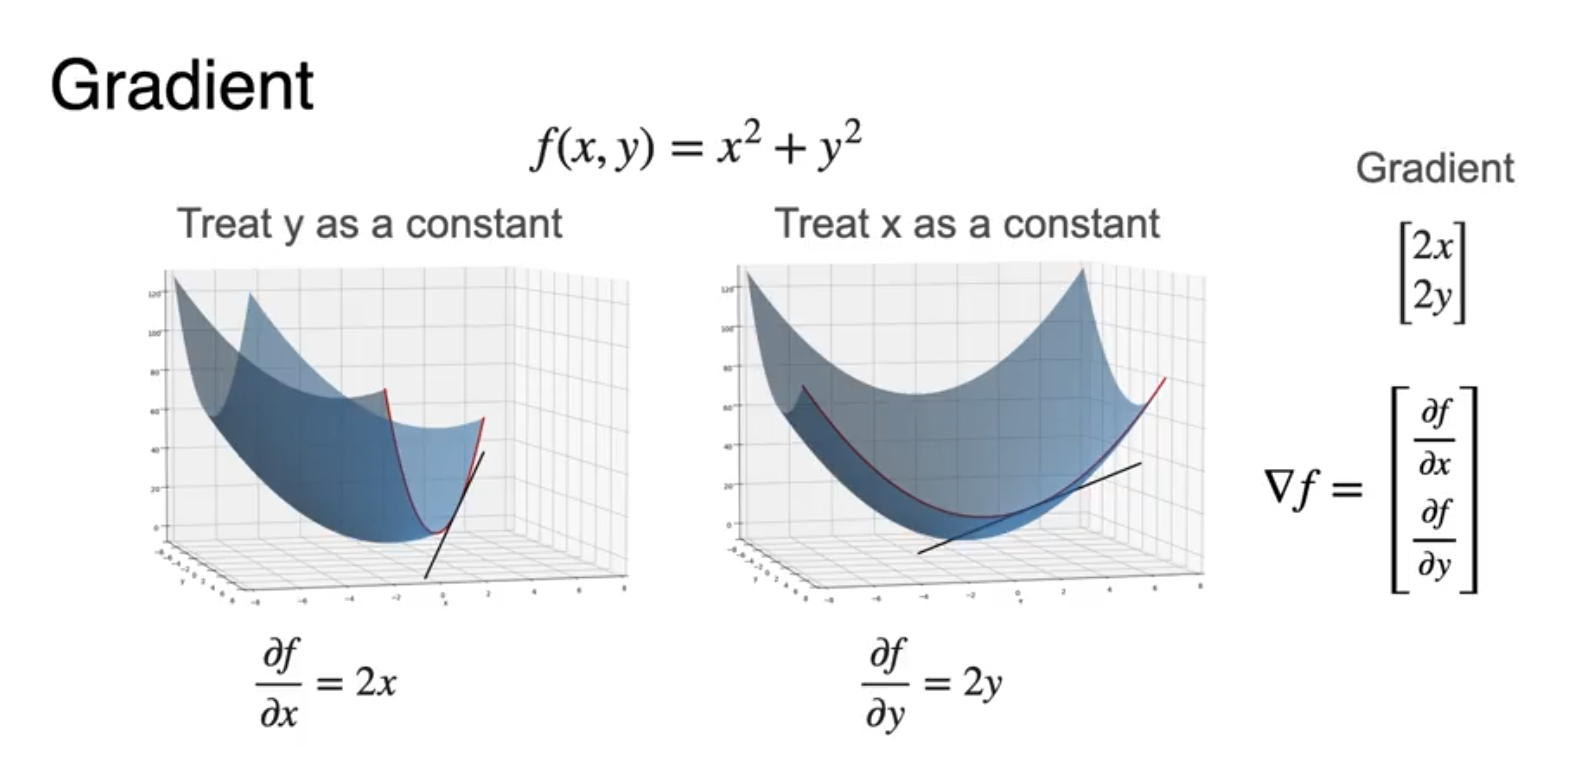

## 3. Definition of the Gradient

For a scalar-valued function

$$
f(x,y)
$$

the gradient is defined as

$$
\nabla f =
\begin{bmatrix}
\frac{\partial f}{\partial x}\\
\frac{\partial f}{\partial y}
\end{bmatrix}
$$

or equivalently:

$$
\nabla f =
\begin{bmatrix}
f_x\\
f_y
\end{bmatrix}
$$

The gradient points in the direction of maximum local increase.


## 4. Worked Example

Let

$$
f(x,y)=x^2+y^2
$$

### Partial derivative with respect to $x$

Treat $y$ as constant:

$$
\frac{\partial f}{\partial x}=2x
$$

### Partial derivative with respect to $y$

Treat $x$ as constant:

$$
\frac{\partial f}{\partial y}=2y
$$

Therefore:

$$
\nabla f =
\begin{bmatrix}
2x\\
2y
\end{bmatrix}
$$


## 5. Visual Summary

The gradient collects both partial derivatives into a vector.

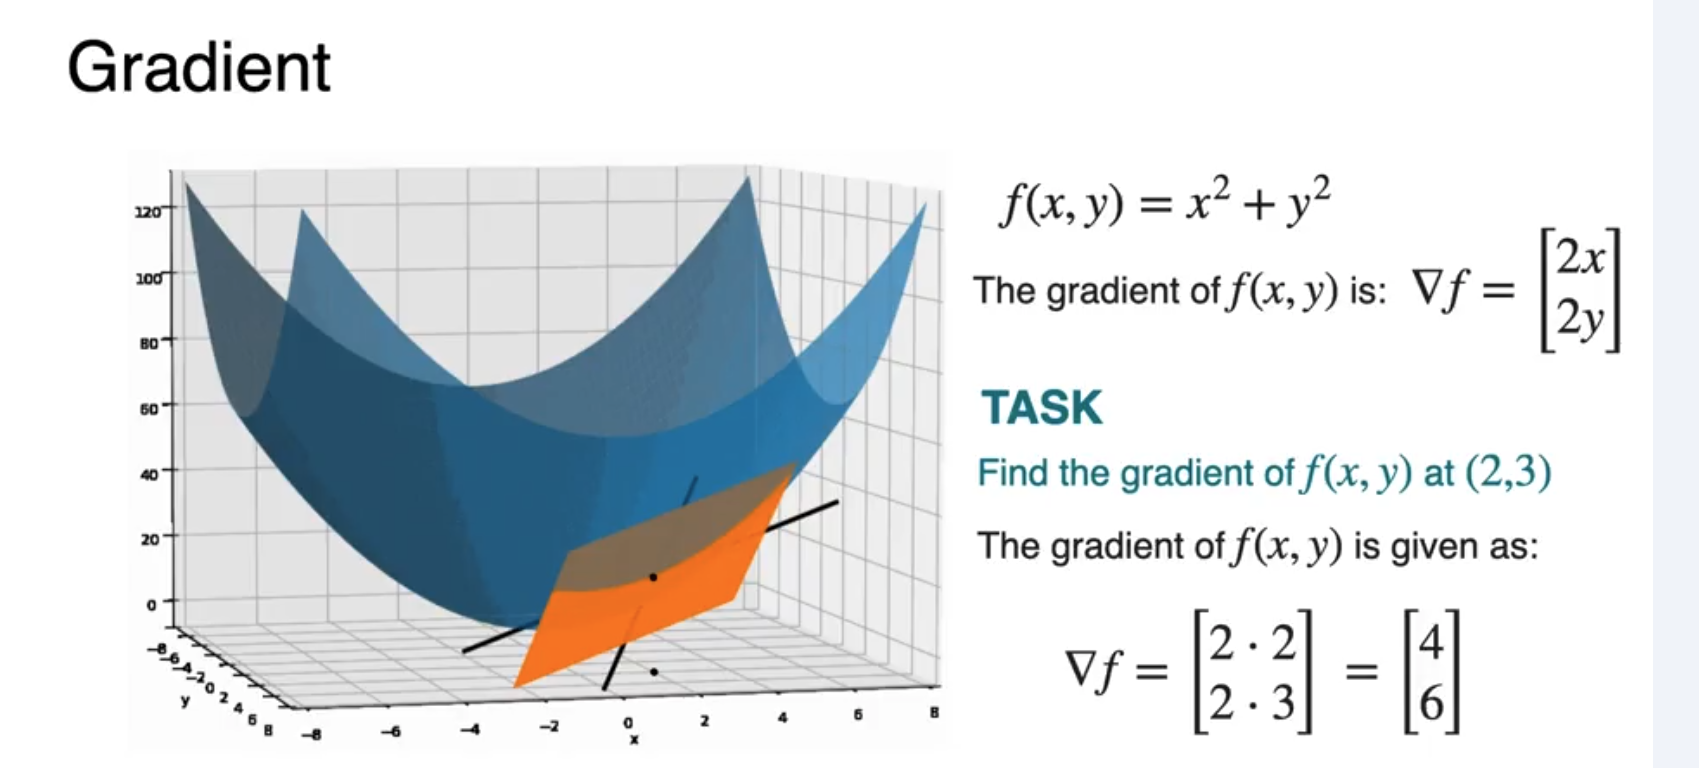

## 6. Evaluate the Gradient at a Point

At $(2,3)$:

$$
\nabla f(2,3)=
\begin{bmatrix}
2\cdot 2\\
2\cdot 3
\end{bmatrix}
=
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$

Interpretation:

At the point $(2,3)$, the direction of steepest increase is the vector

$$
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D

## 7. 3D Surface Visualization

We visualize:

$$
f(x,y)=x^2+y^2
$$

This is a paraboloid.


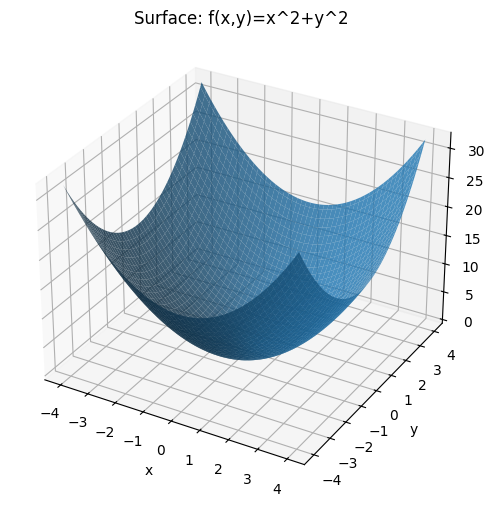

In [2]:
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, alpha=0.8)

ax.set_title("Surface: f(x,y)=x^2+y^2")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

## 8. Symbolic Verification with SymPy

We can compute the partial derivatives symbolically.


In [3]:
x, y = sp.symbols("x y")

f = x**2 + y**2

fx = sp.diff(f, x)
fy = sp.diff(f, y)

gradient = sp.Matrix([fx, fy])

print("f(x,y) =", f)
print("f_x =", fx)
print("f_y =", fy)
print("Gradient:")
gradient

f(x,y) = x**2 + y**2
f_x = 2*x
f_y = 2*y
Gradient:


Matrix([
[2*x],
[2*y]])

## 9. Tangent Plane Connection

The gradient determines the orientation of the tangent plane.

For

$$
z=f(x,y)
$$

at $(x_0,y_0)$, the tangent plane is:

$$
z=f(x_0,y_0)+f_x(x_0,y_0)(x-x_0)+f_y(x_0,y_0)(y-y_0)
$$

The coefficients of $(x-x_0)$ and $(y-y_0)$ are the components of the gradient.


## 10. Gradient and Contours

The gradient is perpendicular to level curves.

A level curve is defined by:

$$
f(x,y)=c
$$

For

$$
f(x,y)=x^2+y^2
$$

the level curves are circles:

$$
x^2+y^2=c
$$

The gradient

$$
\nabla f =
\begin{bmatrix}
2x\\
2y
\end{bmatrix}
$$

points radially outward.


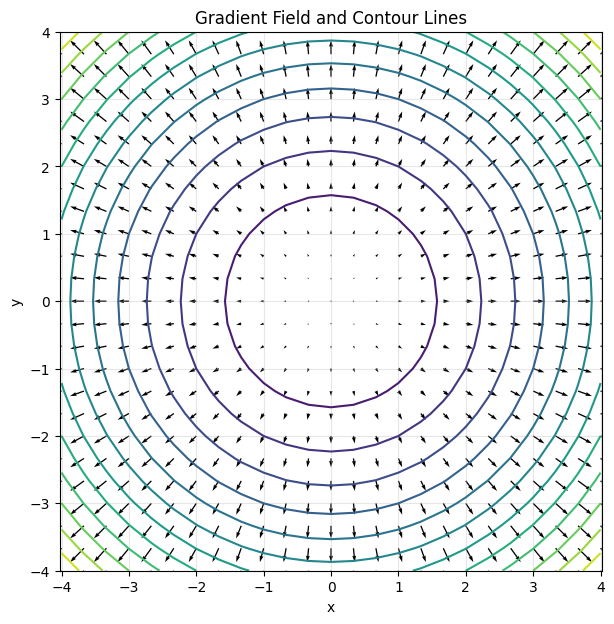

In [4]:
x = np.linspace(-4, 4, 25)
y = np.linspace(-4, 4, 25)
X, Y = np.meshgrid(x, y)

Z = X**2 + Y**2
U = 2 * X
V = 2 * Y

plt.figure(figsize=(7, 7))
plt.contour(X, Y, Z, levels=12)
plt.quiver(X, Y, U, V)

plt.title("Gradient Field and Contour Lines")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## 11. Numerical Approximation of the Gradient

Finite differences approximate partial derivatives.

For the $x$-partial:

$$
\frac{\partial f}{\partial x}
\approx
\frac{f(x+h,y)-f(x,y)}{h}
$$

For the $y$-partial:

$$
\frac{\partial f}{\partial y}
\approx
\frac{f(x,y+h)-f(x,y)}{h}
$$


In [5]:
def f_numeric(x, y):
    return x**2 + y**2

def partial_x(func, x, y, h=1e-5):
    return (func(x + h, y) - func(x, y)) / h

def partial_y(func, x, y, h=1e-5):
    return (func(x, y + h) - func(x, y)) / h

x0, y0 = 2, 3

fx_num = partial_x(f_numeric, x0, y0)
fy_num = partial_y(f_numeric, x0, y0)

print("Numerical gradient:", [fx_num, fy_num])
print("Exact gradient    :", [2*x0, 2*y0])

Numerical gradient: [4.000010000027032, 6.000009999951316]
Exact gradient    : [4, 6]


## 12. Direction of Steepest Ascent

At $(2,3)$, the gradient is:

$$
\nabla f(2,3)=
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$

This vector points in the direction where $f(x,y)$ increases fastest.

The magnitude of the gradient is:

$$
\|\nabla f\|=\sqrt{4^2+6^2}=\sqrt{52}
$$


In [6]:
gradient_at_point = np.array([4, 6])
magnitude = np.linalg.norm(gradient_at_point)

print("Gradient at (2,3):", gradient_at_point)
print("Magnitude:", magnitude)

Gradient at (2,3): [4 6]
Magnitude: 7.211102550927978


## 13. Another Worked Example

Let

$$
f(x,y)=xy
$$

Then:

$$
f_x=y
$$

and

$$
f_y=x
$$

So:

$$
\nabla f =
\begin{bmatrix}
y\\
x
\end{bmatrix}
$$

At $(2,3)$:

$$
\nabla f(2,3)=
\begin{bmatrix}
3\\
2
\end{bmatrix}
$$


In [8]:
f2 = x*y

gradient_f2 = sp.Matrix([
    sp.diff(f2, x),
    sp.diff(f2, y)
])

gradient_f2

ValueError: 
Can't calculate derivative wrt 16.0000000000000.

## 14. Practice Exercises

### Basic

1. Compute the gradient of:

$$
f(x,y)=3x^2+5y^2
$$

2. Compute the gradient of:

$$
f(x,y)=xy
$$

### Intermediate

3. Find the gradient at $(1,-2)$ for:

$$
f(x,y)=x^2+y^2
$$

4. Compute the gradient of:

$$
f(x,y)=\sin(xy)
$$

### Advanced

5. Explain why the gradient is perpendicular to contour lines.

6. Explain why the gradient points in the direction of steepest ascent.


## 15. Solutions

### 1.

$$
\nabla f =
\begin{bmatrix}
6x\\
10y
\end{bmatrix}
$$

### 2.

$$
\nabla f =
\begin{bmatrix}
y\\
x
\end{bmatrix}
$$

### 3.

For

$$
f(x,y)=x^2+y^2
$$

we have:

$$
\nabla f =
\begin{bmatrix}
2x\\
2y
\end{bmatrix}
$$

At $(1,-2)$:

$$
\nabla f(1,-2)=
\begin{bmatrix}
2\\
-4
\end{bmatrix}
$$

### 4.

For

$$
f(x,y)=\sin(xy)
$$

use the chain rule:

$$
f_x = y\cos(xy)
$$

$$
f_y = x\cos(xy)
$$

So:

$$
\nabla f =
\begin{bmatrix}
y\cos(xy)\\
x\cos(xy)
\end{bmatrix}
$$

### 5.

Along a contour line, the value of $f$ does not change. The gradient points in the direction of maximum change, so it must be perpendicular to the direction where there is no change.

### 6.

The directional derivative is largest when the direction vector aligns with the gradient. Therefore, the gradient points in the direction of steepest ascent.


## 16. Conclusion

The gradient is a vector of partial derivatives:

$$
\nabla f =
\begin{bmatrix}
f_x\\
f_y
\end{bmatrix}
$$

For:

$$
f(x,y)=x^2+y^2
$$

we get:

$$
\nabla f =
\begin{bmatrix}
2x\\
2y
\end{bmatrix}
$$

At $(2,3)$:

$$
\nabla f(2,3)=
\begin{bmatrix}
4\\
6
\end{bmatrix}
$$

Key ideas:

- partial derivatives measure change in coordinate directions
- the gradient collects all partial derivatives
- the gradient points in the direction of steepest ascent
- the gradient is perpendicular to contour lines
- the gradient helps define tangent planes and local linear approximations
